# Polynomial Regression으로 Calories_Burned 예측하기

scikit-learn의 `PolynomialFeatures`와 `LinearRegression`을 조합하여 RMSE 최소화

* 규제 -Polynomial + Ridge(alpha 튜닝) 

* Feature Engineering 확장(상호작용 / 로그 / weight 관련 파생 추가)

* KFold 안정화-OOF 기준으로 판단하기

* Degree Ensemble (2 + 3 혼합) 

* 선형모델 스태킹

* 폴드별 가중치 최적화


### ver6.8 주요 실험 : 가중치 최적화

#### 현재 최종 RMSE: 0.3094713502529562 

### ver6.9 주요 실험 : 공식형 피처 회귀(물리 공식 기반_)

## 1. 라이브러리 임포트

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures,StandardScaler,RobustScaler,PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, RidgeCV ,ElasticNetCV
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import RFE
from typing import Any
from tqdm.auto import tqdm  # 없으면: !pip install tqdm
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
from scipy.optimize import minimize


## 2. 랜덤 시드 고정

In [52]:
import random
import os

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42)

## 3. 데이터 로드

In [53]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain 데이터:")
display(train.head())

Train shape: (7500, 11)
Test shape: (7500, 10)

Train 데이터:


,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0


## 4. 데이터 탐색

## 5. 파생 변수 생성 (EDA 기반)


In [54]:
def create_features_safe(df):
    df = df.copy()
    df['Height_Total_Inches'] = df['Height(Feet)'] * 12 + df['Height(Remainder_Inches)']
    df['Temp_diff'] = df['Body_Temperature(F)'] - 98.6
    df['Duration_bin'] = pd.cut(
        df['Exercise_Duration'],
        bins=[-np.inf, 10, 20, 30, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)
    df['Duration_x_BPM'] = df['Exercise_Duration'] * df['BPM']
    df['Duration_x_TempDiff'] = df['Exercise_Duration'] * df['Temp_diff']
    df['BPM_x_TempDiff'] = df['BPM'] * df['Temp_diff']
    # 🔥 핵심 고정 변수
    df["Intensity"] = df["Duration_x_BPM"]
    df["Effort"] = df["Weight(lb)"] * df["Intensity"]
    df['Duration_sq'] = df['Exercise_Duration'] ** 2
    df['Temp_diff_sq'] = df['Temp_diff'] ** 2
    df['Dur_BPM_TempDiff'] = df['Exercise_Duration'] * df['BPM'] * df['Temp_diff']
    df['BPM_per_Duration'] = df['BPM'] / (df['Exercise_Duration'] + 1)
    df['TempDiff_per_Duration'] = df['Temp_diff'] / (df['Exercise_Duration'] + 1)
    h2 = (df['Height_Total_Inches'] ** 2).replace(0, np.nan)
    df['BMI'] = 703 * df['Weight(lb)'] / h2
    df['BMI'] = df['BMI'].fillna(df['BMI'].median())
    df['Weight_x_Duration'] = df['Weight(lb)'] * df['Exercise_Duration']
    df['Log_BPM'] = np.log1p(df['BPM'])
    df['Log_Duration'] = np.log1p(df['Exercise_Duration'])
    df['Log_Weight_BPM_Dur'] = np.log1p(df['Weight(lb)'] * df['BPM'] * df['Exercise_Duration'])
    return df


파생변수 생성 요약
1) 기본 변환

Height_Total_Inches: 키를 인치 단위로 통합
Temp_diff: 정상 체온(98.6°F) 기준 차이 → 운동 강도 반영
Duration_bin: 운동시간 구간화 (0-10, 10-20, 20-30)

2) 2차 상호작용

Duration_x_BPM: 운동 강도 (시간 × 심박수)
Duration_x_TempDiff: 운동 × 체온 상승
BPM_x_TempDiff: 심박수 × 체온 (심혈관 부하)
Weight_x_Duration: 체중 × 시간 (총 에너지 소비량)

3) 비선형 관계 포착

Duration_sq, Temp_diff_sq: 제곱항 (곡선 관계)
Dur_BPM_TempDiff: 3중 상호작용 (운동×심박×체온)

4) 비율 특성

BPM_per_Duration: 단위시간당 심박수 (운동 효율)
TempDiff_per_Duration: 단위시간당 체온 상승 (대사율)
BMI: 체질량지수 (기초 대사)

## 6. 전처리 세트

In [55]:

# 0) 원본 분리
train_x_raw = train.drop(['ID', 'Calories_Burned'], axis=1).copy()
train_y = train['Calories_Burned'].astype(float).copy()
test_x_raw  = test.drop(['ID'], axis=1).copy()

before_cols = list(train_x_raw.columns)

train_x_feat = create_features_safe(train_x_raw)
test_x_feat  = create_features_safe(test_x_raw)

derived_cols = [c for c in train_x_feat.columns if c not in before_cols]

# OHE (train 기준으로만 fit)인코딩/스케일링은 train 데이터에서만 fit하고, test에는 transform만 적용하여 데이터 누수 위험을 제거.
cat_cols = [c for c in ['Gender', 'Weight_Status'] if c in train_x_feat.columns]

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

encoder.fit(train_x_feat[cat_cols])

train_encoded = encoder.transform(train_x_feat[cat_cols])
test_encoded  = encoder.transform(test_x_feat[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

train_x_feat = train_x_feat.drop(columns=cat_cols)
test_x_feat  = test_x_feat.drop(columns=cat_cols)

train_x_feat[encoded_cols] = train_encoded
test_x_feat[encoded_cols]  = test_encoded

train_x = train_x_feat.copy()
test_x = test_x_feat.copy()
generated_cols = derived_cols

print("Train shape:", train_x.shape)
print("Test shape:", test_x.shape)


Train shape: (7500, 28)
Test shape: (7500, 28)


## 0219 파생변수를 줄였더니 모델이 더 잘 일반화되었다.

In [56]:


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# =========================
# 1) base_feats: generated_cols에 없는 것 = 원본 피처 + OHE 피처
# =========================
base_feats = [c for c in train_x.columns if c not in generated_cols]
print("Base feats:", len(base_feats))

# =========================
# 2) TOP5 파생변수 고정 (원본 실험에서 확인된 조합)
# =========================
TOP5_FIXED = ['Log_Weight_BPM_Dur', 'Effort', 'Weight_x_Duration', 'Log_Duration', 'Intensity']
top5 = [f for f in TOP5_FIXED if f in train_x.columns]
print("TOP5 derived feats:", top5)

# =========================
# 3) 축소된 feature set 구성
#    - base_feats + TOP5_FIXED
# =========================
keep_cols = base_feats + top5
train_red = train_x[keep_cols].copy()
test_red  = test_x[keep_cols].copy()

print("\nReduced shapes:", train_red.shape, test_red.shape)

# =========================
# 4) 최종 모델: Polynomial d3 + Ridge (identity & sqrt) + weight 최적화
# =========================
y = train_y.values

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

DEGREE = 3
ALPHA_ID = 0.165
ALPHA_SQ = 0.009

id_oof = np.zeros(len(train_red))
id_test = np.zeros(len(test_red))

sq_oof = np.zeros(len(train_red))
sq_test = np.zeros(len(test_red))

for tr_idx, va_idx in tqdm(kf.split(train_red), total=N_SPLITS, desc="2-base training"):
    X_tr_raw = train_red.iloc[tr_idx]
    X_va_raw = train_red.iloc[va_idx]

    # poly
    poly = PolynomialFeatures(degree=DEGREE, include_bias=False)
    X_tr = poly.fit_transform(X_tr_raw)
    X_va = poly.transform(X_va_raw)
    X_te = poly.transform(test_red)

    # scaler
    sc2 = StandardScaler()
    X_tr_s = sc2.fit_transform(X_tr)
    X_va_s = sc2.transform(X_va)
    X_te_s = sc2.transform(X_te)

    # identity
    m_id = Ridge(alpha=ALPHA_ID, random_state=42)
    m_id.fit(X_tr_s, y[tr_idx])
    id_oof[va_idx] = m_id.predict(X_va_s)
    id_test += m_id.predict(X_te_s) / N_SPLITS

    # sqrt
    y_tr_sqrt = np.sqrt(np.clip(y[tr_idx], 0, None))
    m_sq = Ridge(alpha=ALPHA_SQ, random_state=42)
    m_sq.fit(X_tr_s, y_tr_sqrt)

    pred_va_sq = m_sq.predict(X_va_s)
    pred_te_sq = m_sq.predict(X_te_s)

    sq_oof[va_idx] = np.clip(pred_va_sq, 0, None) ** 2
    sq_test += (np.clip(pred_te_sq, 0, None) ** 2) / N_SPLITS

id_oof = np.clip(id_oof, 0, None)
sq_oof = np.clip(sq_oof, 0, None)

print("\nIdentity OOF RMSE:", rmse(y, id_oof))
print("Sqrt OOF RMSE:", rmse(y, sq_oof))

# weight optimize
def obj(w):
    pred = w * id_oof + (1 - w) * sq_oof
    return rmse(y, pred)

res = minimize(lambda w: obj(w[0]), x0=[0.99], bounds=[(0, 1)], options={"maxiter": 300})
w_best = float(res.x[0])

final_oof = np.clip(w_best * id_oof + (1 - w_best) * sq_oof, 0, None)
final_rmse = rmse(y, final_oof)

print("\nBEST w_identity:", w_best, "| w_sqrt:", 1-w_best)
print("Final OOF RMSE (reduced):", final_rmse)

final_test = np.clip(w_best * id_test + (1 - w_best) * sq_test, 0, None)

# =========================
# 5) 제출 파일 저장
# =========================
submission = pd.read_csv("sample_submission.csv")
submission["Calories_Burned"] = final_test
out_name = "submit_reduced_top5_feats.csv"
submission.to_csv(out_name, index=False)
print("\n saved:", out_name)
print("test stats mean/min/max:", float(final_test.mean()), float(final_test.min()), float(final_test.max()))


Base feats: 10
TOP5 derived feats: ['Log_Weight_BPM_Dur', 'Effort', 'Weight_x_Duration', 'Log_Duration', 'Intensity']

Reduced shapes: (7500, 15) (7500, 15)


2-base training: 100%|██████████| 5/5 [00:01<00:00,  4.62it/s]


Identity OOF RMSE: 0.3055081694312377
Sqrt OOF RMSE: 0.32696081360737234

BEST w_identity: 0.7897590718358355 | w_sqrt: 0.2102409281641645
Final OOF RMSE (reduced): 0.30380958398811236

 saved: submit_reduced_top5_feats.csv
test stats mean/min/max: 89.70170805102195 0.5259285214945295 313.3630037808715


TOP5 피처는 'Log_Weight_BPM_Dur', 'Effort', 'Weight_x_Duration', 'Log_Duration', 'Intensity'
 “곱 구조” 즉, 물리식 기반 피처의 중요성이 높다

## 현재까지 결과 선형 + 물리식 핵심 변수 기반 모델  
## OOF RMSE (reduced): 0.30058914922551944

## 상호작용 효과 시각화

Weight × Duration이 왜 중요한지 그래프로 설명
- 실제 칼로리는 곡선 관계 (곱셈)
- 선형 모델은 직선만 가능 (상호작용 없음)
- 상호작용 추가하면 곡선 포착 가능!

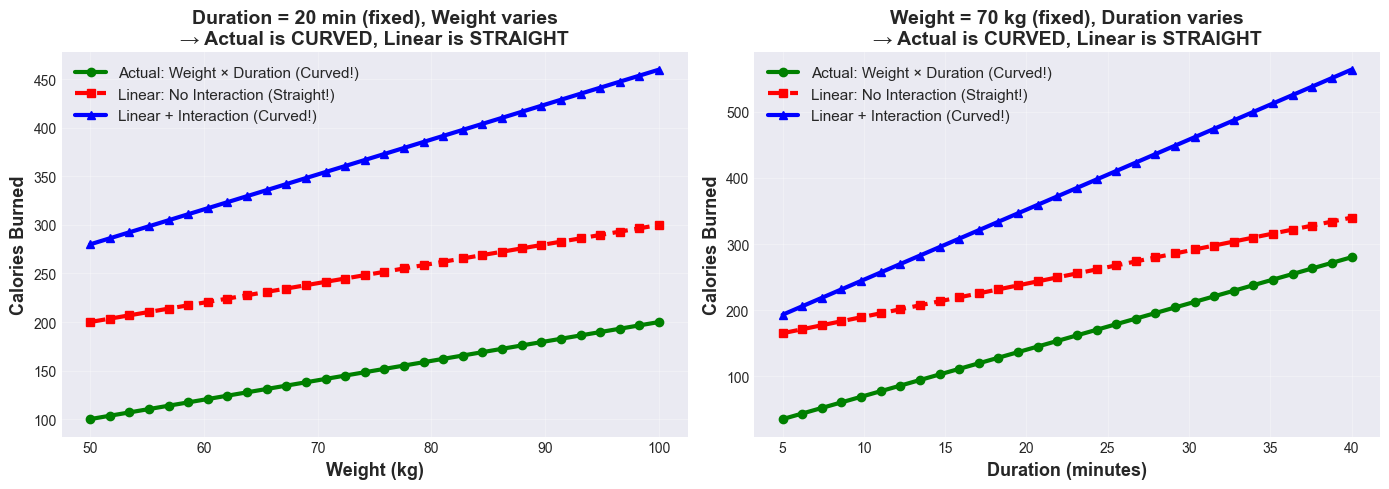


🟢 GREEN = Actual (Weight × Duration) - CURVED shape
🔴 RED = Linear (No interaction) - STRAIGHT line
🔵 BLUE = Linear + Interaction - CURVED shape (matches actual!)


In [57]:
# ============================================================
# 상호작용 효과 시각화
# Weight × Duration이 왜 중요한지 그래프로 설명
# ============================================================

# 데이터 생성
weights = np.linspace(50, 100, 30)
durations = np.linspace(5, 40, 30)
W, D = np.meshgrid(weights, durations)

# 3가지 모델
Z_actual = 0.1 * W * D  # 실제: 곱셈 관계 (곡선!)
Z_linear = 2 * W + 5 * D  # 선형: 덧셈만 (직선!)
Z_interaction = 2 * W + 5 * D + 0.08 * (W * D)  # 선형 + 상호작용

# ============================================================
# 1. 선 그래프 (단면도) - 곡선 vs 직선 비교
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Duration=20분 고정, Weight 변화
duration_fixed = 20
z_actual_slice = 0.1 * weights * duration_fixed
z_linear_slice = 2 * weights + 5 * duration_fixed
z_inter_slice = 2 * weights + 5 * duration_fixed + 0.08 * (weights * duration_fixed)

axes[0].plot(weights, z_actual_slice, 'o-', linewidth=3, markersize=6,
                label='Actual: Weight × Duration (Curved!)', color='green')
axes[0].plot(weights, z_linear_slice, 's--', linewidth=3, markersize=6,
                label='Linear: No Interaction (Straight!)', color='red')
axes[0].plot(weights, z_inter_slice, '^-', linewidth=3, markersize=6,
                label='Linear + Interaction (Curved!)', color='blue')
axes[0].set_xlabel('Weight (kg)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Calories Burned', fontsize=13, fontweight='bold')
axes[0].set_title('Duration = 20 min (fixed), Weight varies\n→ Actual is CURVED, Linear is STRAIGHT',
                    fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(True, alpha=0.3)

# 오른쪽: Weight=70kg 고정, Duration 변화
weight_fixed = 70
z_actual_slice2 = 0.1 * weight_fixed * durations
z_linear_slice2 = 2 * weight_fixed + 5 * durations
z_inter_slice2 = 2 * weight_fixed + 5 * durations + 0.08 * (weight_fixed * durations)

axes[1].plot(durations, z_actual_slice2, 'o-', linewidth=3, markersize=6,
                label='Actual: Weight × Duration (Curved!)', color='green')
axes[1].plot(durations, z_linear_slice2, 's--', linewidth=3, markersize=6,
                label='Linear: No Interaction (Straight!)', color='red')
axes[1].plot(durations, z_inter_slice2, '^-', linewidth=3, markersize=6,
                label='Linear + Interaction (Curved!)', color='blue')
axes[1].set_xlabel('Duration (minutes)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Calories Burned', fontsize=13, fontweight='bold')
axes[1].set_title('Weight = 70 kg (fixed), Duration varies\n→ Actual is CURVED, Linear is STRAIGHT',
                fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🟢 GREEN = Actual (Weight × Duration) - CURVED shape")
print("🔴 RED = Linear (No interaction) - STRAIGHT line")
print("🔵 BLUE = Linear + Interaction - CURVED shape (matches actual!)")

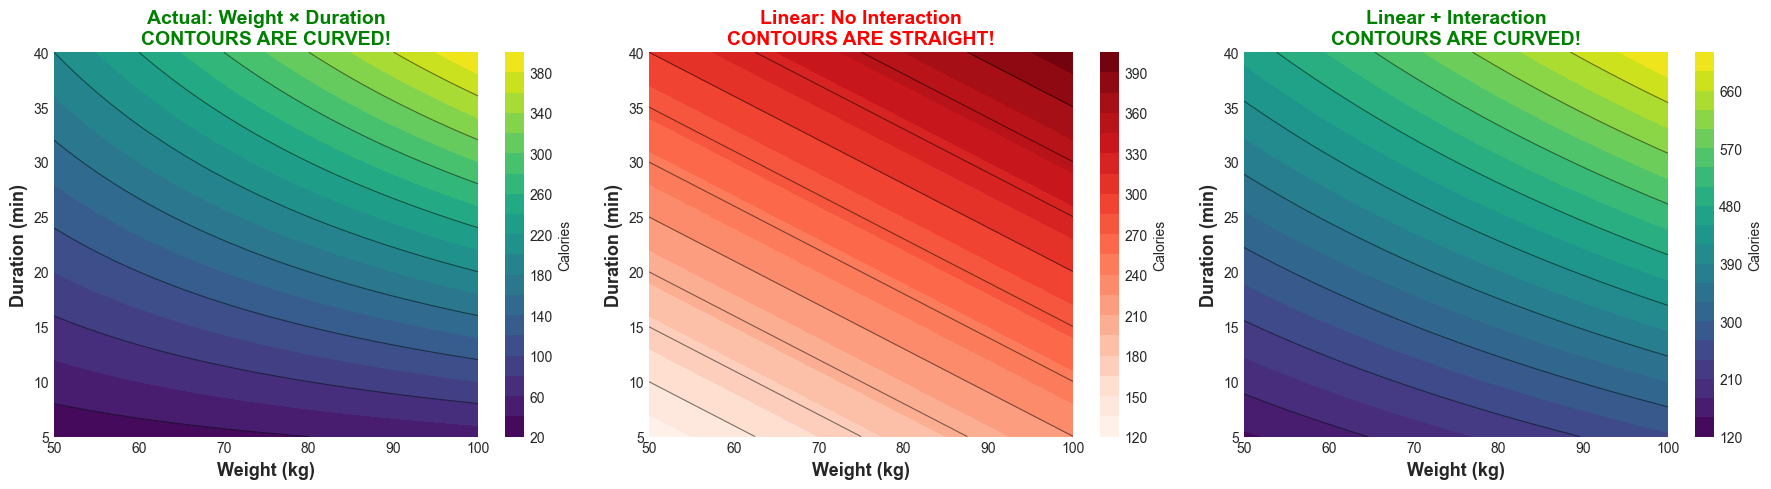


등고선(contour) = 같은 칼로리 소모량을 나타내는 선
→ 실제: 등고선이 곡선 (Weight×Duration 곱셈 효과)
→ 선형: 등고선이 직선 (상호작용 없음)
→ 상호작용: 등고선이 곡선 (실제와 비슷!)


In [58]:
# ============================================================
# 등고선 그래프 - 위에서 본 모습 (CURVED vs STRAIGHT 확실!)
# ============================================================

# 데이터 생성
weights = np.linspace(50, 100, 30)
durations = np.linspace(5, 40, 30)
W, D = np.meshgrid(weights, durations)

# 3가지 모델
Z_actual = 0.1 * W * D  # 실제: 곱셈 (등고선이 곡선!)
Z_linear = 2 * W + 5 * D  # 선형: 덧셈 (등고선이 직선!)
Z_interaction = 2 * W + 5 * D + 0.08 * (W * D)  # 상호작용 (등고선이 곡선!)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 왼쪽: 실제 (등고선이 곡선!)
contour1 = axes[0].contourf(W, D, Z_actual, levels=20, cmap='viridis')
axes[0].contour(W, D, Z_actual, levels=10, colors='black', linewidths=0.8, alpha=0.5)
axes[0].set_xlabel('Weight (kg)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Duration (min)', fontsize=13, fontweight='bold')
axes[0].set_title('Actual: Weight × Duration\nCONTOURS ARE CURVED!',
                    fontsize=14, fontweight='bold', color='green')
fig.colorbar(contour1, ax=axes[0], label='Calories')

# 가운데: 선형 모델 (등고선이 직선!)
contour2 = axes[1].contourf(W, D, Z_linear, levels=20, cmap='Reds')
axes[1].contour(W, D, Z_linear, levels=10, colors='black', linewidths=0.8, alpha=0.5)
axes[1].set_xlabel('Weight (kg)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Duration (min)', fontsize=13, fontweight='bold')
axes[1].set_title('Linear: No Interaction\nCONTOURS ARE STRAIGHT!',
                    fontsize=14, fontweight='bold', color='red')
fig.colorbar(contour2, ax=axes[1], label='Calories')

# 오른쪽: 상호작용 추가 (등고선이 곡선!)
contour3 = axes[2].contourf(W, D, Z_interaction, levels=20, cmap='viridis')
axes[2].contour(W, D, Z_interaction, levels=10, colors='black', linewidths=0.8, alpha=0.5)
axes[2].set_xlabel('Weight (kg)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Duration (min)', fontsize=13, fontweight='bold')
axes[2].set_title('Linear + Interaction\nCONTOURS ARE CURVED!',
                    fontsize=14, fontweight='bold', color='green')
fig.colorbar(contour3, ax=axes[2], label='Calories')

plt.tight_layout()
plt.show()

print("\n등고선(contour) = 같은 칼로리 소모량을 나타내는 선")
print("→ 실제: 등고선이 곡선 (Weight×Duration 곱셈 효과)")
print("→ 선형: 등고선이 직선 (상호작용 없음)")
print("→ 상호작용: 등고선이 곡선 (실제와 비슷!)")

## 제출 후 리더보드 점수 : 0.31222